<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>


# Laboratorium nr 1: Sieci neuronowe - perceptron

## Perceptron
![perceptron](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/neuron2.PNG)![eq](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/n2eq2.PNG)

### Uczenie perceptronu
Uczenie perceptronu należy do grupy uczenia z nauczycielem i polega na takim doborze wektora wag $w$, aby sygnał wyjściowy neuronu $y$ były najbliżej wartości pożądanej $d$. Najpopularniejszą metodą uczenia perceptronu jest tzw. _reguła perceptronu_, którą można opisać w postaci kilku kroków.

Załóżmy, że dysponujemy zbiorem wektorów uczących postaci $\{x^{(0)}, x^{(1)}, \ldots, x^{(P)}\}$ oraz odpowiadającym mu zbiorem wartości pożądanych $\{d^{(0)}, d^{(1)},\ldots, d^{(P)}\}$.

#### Reguła perceptronu
1. Ustalamy $t = 0$.
2. Ustalamy w sposób losowy początkowe wartości wektora wag $w$.
3. Prezentujemy na wejścia perceptronu wektor uczący $x^{(t)}$.
4. Obliczamy odpowiedź perceptronu $y$ zgodnie z wzorem $y = g\left(\sum\limits_{i=0}^N{w_ix^{(t)}_i}\right)$, gdzie $g$ to fukcja skoku zwracająca $1$ gdy argument jest większy od $0$, a w przeciwnym wypadku $0$.
5. Porównujemy odpowiedź perceptronu $y$ z pożądaną odpowiedzią $d^{(t)}$.
6. Modyfikujemy wartości wag według poniższych reguł, parametr $\eta\in(0,1)$ to _współczynnuk uczenia_:
   - jeśli $y = d^{(t)}$ to wagi pozostają niezmienione,
   - jeśli $y = 0$, a $d^{(t)}=1$ to $w_i = w_i + \eta x_i^{(t)}$,
   - jeśli $y = 1$, a $d^{(t)}=0$ to $w_i = w_i - \eta x_i^{(t)}$.
7. Jeżeli warunek zatrzymania nie jest spełniony, to ustalamy $t = t + 1$ i wracamy do kroku 3, w przeciwnym przypadku kończymy algorytm.

Wykonanie powyższej procedury dla wszystkich wektorów uczących nazywamy _epoką uczenia_. W przypadku uczenia perceptronu wykonujemy tyle epok, aż wszystkie przykłady uczące będą dobrze sklasyfikowane lub błąd klasyfikacji będzie dostatecznie mały. Stabilność oraz szybkość uczenia tym algorytmem w istotny sposób zależy od doboru
parametru $\eta$. Współczynnik ten dobierany jest najczęściej w sposób empiryczny.

## Ćwiczenie 1:
Zaimplementuj model preceptronu w postaci klasy.

In [ ]:
import numpy as np

class Perceptron:
    # Inicjalizator, ustawiający atrybut self.w oraz self.b jako wektor losowych wag, n ilość sygnałów wejściowych
    def __init__(self, n, bias=True):
        pass

    # Metoda obliczająca odpowiedz modelu dla zadanego sygnału wejściowego x=[x1,x2,...,xN]
    def predict(self, x):
        pass


    # Metoda uczenia według reguły perceptronu, xx - zbiór danych uczących, d - odpowiedzi,
    # eta - współczynnik uczenia,
    # tol - tolerancja (czyli jak duży błąd jesteśmy w stanie zaakceptować)
    def train(self, xx, d, eta, tol=0, maxepoch=10000, verbose=1):
        pass

    # Metoda obliczająca błąd dla danych testowych xx
    # zwraca błąd oraz wektor odpowiedzi perceptronu dla danych testowych
    def evaluate_test(self, xx, d):
        pass


## Ćwiczenie 2:
- Stwórz dwa obiekty klasy `Perceptron`.
- Wczytaj dane z plików `2D.csv` oraz `3D.csv.`
- Pierwszy z perceptronów naucz klasyfikować dane z pliku `2D.csv`, ucz tylko na losowej części danych (np. 80%)
- Drugi z perceptronów naucz klasyfikować dane z pliku `3D.csv`, ucz tylko na losowej części danych (np. 80%)
- Oba zbiory danych są przykładami problemów liniowo separowalnych, a więc należy uczyć modele tak aby uzyskiwać dla danych uczących błąd równy zero.
- Przedstaw rezultaty uczenia na wykresach, odpowiednio 2D lub 3D. Na wykresach powinny znaleźć się dane testowe, tzn. te które nie były wykorzystywane w trakcie uczenia oraz linia (płaszczyzna) rozdzielająca klasy.

In [14]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('2D.csv', skiprows=1, delimiter=';', names=['X1', 'X2', 'L'], decimal=',')
df.head()

,X1,X2,L
0,-0.036819,-0.885263,0
1,-0.576998,-0.367745,1
2,0.397497,-0.418429,0
3,-0.288463,0.801790,1
4,0.829187,-0.350243,0


## Ćwiczenie 3:
Wybierz 2 dowolne klasy ze zbioru danych MNIST i wytrenuj model perceptronu do ich rozróżniania.

### Baza MNIST

- Baza MNIST zawiera zbiór trenujący składający się z 60,000 przykładów skanów ręcznie pisanych cyfr od 0 do 9 (problem klasyfikacyjny z 10 klasami).
- Zbiór testowy zawiera 10,000 przykładów.
- Każdy obraz ma rozmiar 28x28 pikseli. Stanowią one 28 * 28 = 784 wejść do sieci.
- W zagadnieniach rozpoznawania obrazów baza MNIST pełni rolę swoistego problemu `Hello world`.

#### Pobieranie bazy MNIST
- Najwygodniej jednak jest użyć bazy MNIST z wykorzystaniem biblioteki Keras

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [23]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
train_images = np.expand_dims(train_images, axis=-1)/255.
train_labels = np.int64(train_labels)
test_images = np.expand_dims(test_images, axis=-1)/255.
test_labels = np.int64(test_labels)
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


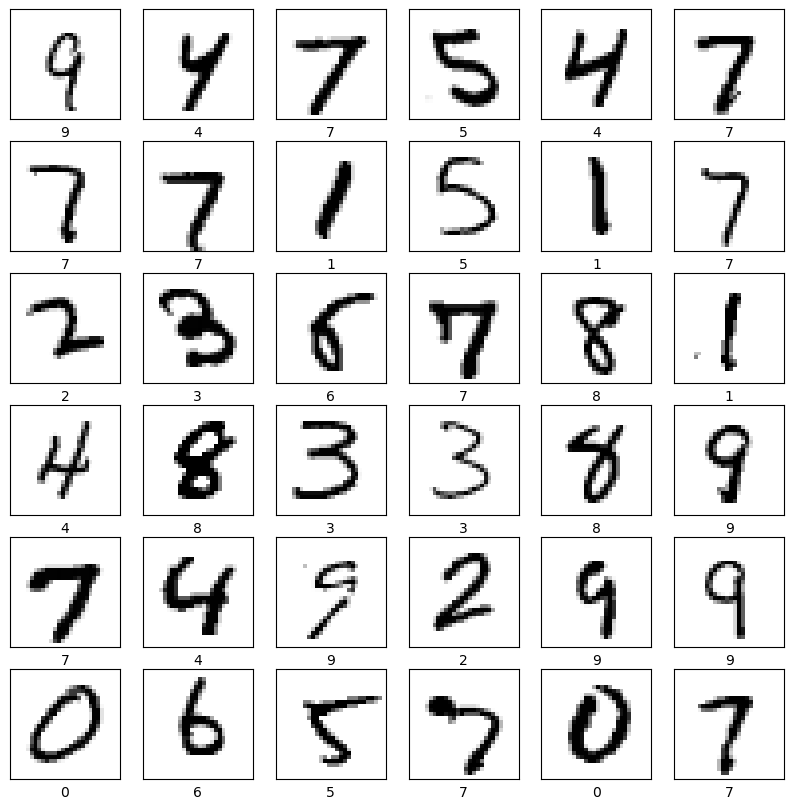

In [24]:
plt.figure(figsize=(10,10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])